In [2]:
import pandas as pd

# Cargamos la información general de los estudiantes
student_info = pd.read_csv("../data/raw/studentInfo.csv")

# Mostramos las primeras 5 filas
student_info.head()
# Tamaño del dataset
print("Cantidad de filas:", student_info.shape[0])
print("Cantidad de columnas:", student_info.shape[1])

# Nombres de las columnas
print("\nColumnas:")
print(student_info.columns.tolist())


Cantidad de filas: 32593
Cantidad de columnas: 12

Columnas:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']


In [3]:
# Información general del dataset
student_info.info()

# Cantidad de valores nulos por columna
print("\nValores nulos:")
print(student_info.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 4.8 MB

Valores nulos:
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_e

In [4]:
# Reemplazamos los valores faltantes de imd_band por "Unknown"
student_info["imd_band"] = student_info["imd_band"].fillna("Unknown")

# Comprobamos que ya no existan valores nulos
print("Valores nulos después de la limpieza:")
print(student_info.isnull().sum())

Valores nulos después de la limpieza:
code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64


In [5]:
# Resumen estadístico de las variables numéricas
student_info.describe()

,id_student,num_of_prev_attempts,studied_credits
count,3.259300e+04,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691
std,5.491673e+05,0.479758,41.071900
min,3.733000e+03,0.000000,30.000000
25%,5.085730e+05,0.000000,60.000000
50%,5.903100e+05,0.000000,60.000000
75%,6.444530e+05,0.000000,120.000000
max,2.716795e+06,6.000000,655.000000


In [6]:
# Resumen de las variables categóricas
student_info.describe(include="str")

,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,disability,final_result
count,32593,32593,32593,32593,32593,32593,32593,32593,32593
unique,7,4,2,13,5,11,3,2,4
top,BBB,2014J,M,Scotland,A Level or Equivalent,20-30%,0-35,N,Pass
freq,7909,11260,17875,3446,14045,3654,22944,29429,12361


In [7]:
# Cantidad de estudiantes según resultado final
resultados = student_info["final_result"].value_counts()

print("Resultados finales:")
print(resultados)

# Porcentaje de cada resultado
print("\nPorcentajes:")
print(student_info["final_result"].value_counts(normalize=True) * 100)

Resultados finales:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

Porcentajes:
final_result
Pass           37.925321
Withdrawn      31.160065
Fail           21.636548
Distinction     9.278066
Name: proportion, dtype: float64


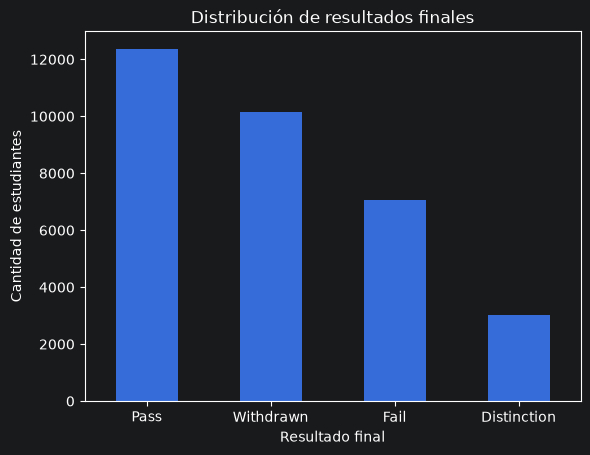

In [8]:
# Distribución de los resultados finales

import matplotlib.pyplot as plt

student_info["final_result"].value_counts().plot(kind="bar")

plt.title("Distribución de resultados finales")
plt.xlabel("Resultado final")
plt.ylabel("Cantidad de estudiantes")
plt.xticks(rotation=0)
plt.show()

final_result  Distinction  Fail  Pass  Withdrawn
gender                                          
F                    1394  3103  5735       4486
M                    1630  3949  6626       5670


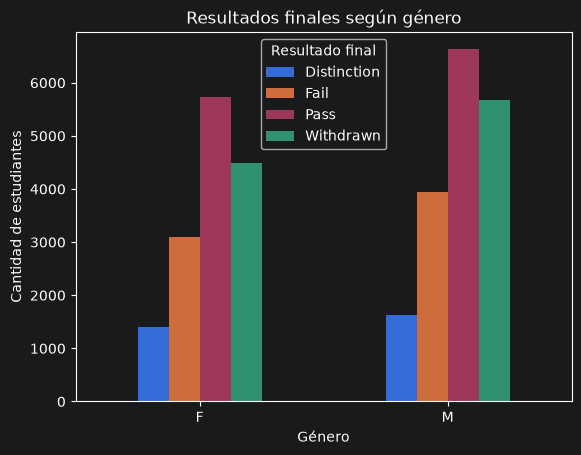

In [9]:
# Resultados finales según género

tabla_genero = pd.crosstab(
    student_info["gender"],
    student_info["final_result"]
)

print(tabla_genero)

tabla_genero.plot(kind="bar")

plt.title("Resultados finales según género")
plt.xlabel("Género")
plt.ylabel("Cantidad de estudiantes")
plt.xticks(rotation=0)
plt.legend(title="Resultado final")
plt.show()

final_result                 Distinction  Fail  Pass  Withdrawn
highest_education                                              
A Level or Equivalent               1496  2707  5812       4030
HE Qualification                     697   790  1960       1283
Lower Than A Level                   727  3426  4385       4620
No Formal quals                       16    95    87        149
Post Graduate Qualification           88    34   117         74


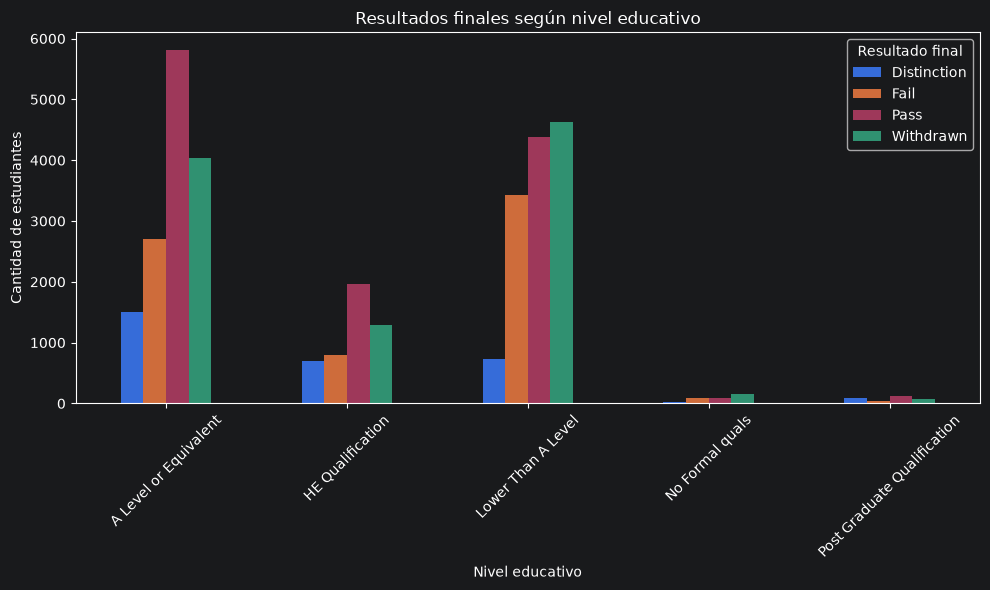

In [10]:
# Resultados finales según nivel educativo

tabla_educacion = pd.crosstab(
    student_info["highest_education"],
    student_info["final_result"]
)

print(tabla_educacion)

tabla_educacion.plot(kind="bar", figsize=(10, 6))

plt.title("Resultados finales según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Cantidad de estudiantes")
plt.xticks(rotation=45)
plt.legend(title="Resultado final")
plt.tight_layout()
plt.show()

final_result                 Distinction   Fail   Pass  Withdrawn
highest_education                                                
A Level or Equivalent              10.65  19.27  41.38      28.69
HE Qualification                   14.74  16.70  41.44      27.12
Lower Than A Level                  5.53  26.04  33.33      35.11
No Formal quals                     4.61  27.38  25.07      42.94
Post Graduate Qualification        28.12  10.86  37.38      23.64


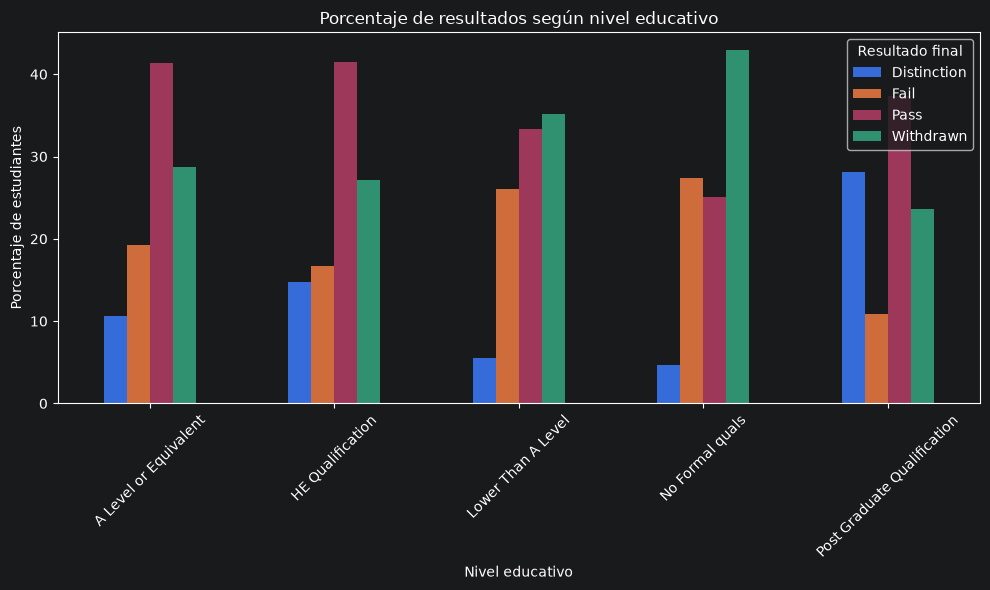

In [11]:
# Porcentaje de resultados dentro de cada nivel educativo

tabla_educacion_pct = pd.crosstab(
    student_info["highest_education"],
    student_info["final_result"],
    normalize="index"
) * 100

print(tabla_educacion_pct.round(2))

tabla_educacion_pct.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Porcentaje de resultados según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Porcentaje de estudiantes")
plt.xticks(rotation=45)
plt.legend(title="Resultado final")
plt.tight_layout()
plt.show()

final_result  Distinction   Fail   Pass  Withdrawn
age_band                                          
0-35                 8.12  22.80  36.91      32.17
35-55               11.87  19.00  40.28      28.85
55<=                18.98  13.43  42.59      25.00


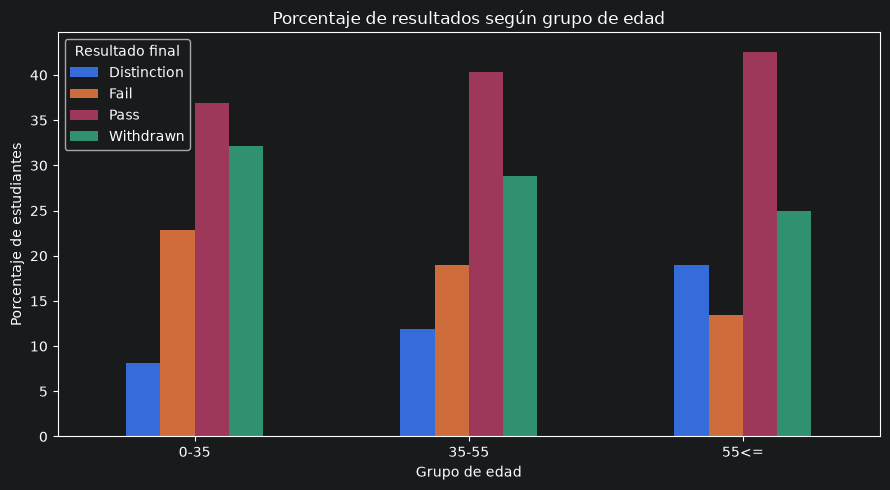

In [12]:
# Resultados finales según grupo de edad

tabla_edad = pd.crosstab(
    student_info["age_band"],
    student_info["final_result"],
    normalize="index"
) * 100

print(tabla_edad.round(2))

tabla_edad.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Porcentaje de resultados según grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Porcentaje de estudiantes")
plt.xticks(rotation=0)
plt.legend(title="Resultado final")
plt.tight_layout()
plt.show()

In [13]:
# Guardamos el dataset limpio en la carpeta processed

student_info.to_csv(
    "../data/processed/student_info_clean.csv",
    index=False
)

print("Archivo guardado correctamente.")

Archivo guardado correctamente.


# Conclusiones del análisis

El análisis realizado sobre los datos de los estudiantes permitió identificar diferentes patrones relacionados con los resultados académicos.

## Resultados generales

La categoría **Pass** presenta la mayor cantidad de registros, con 12,361 casos (37.93%). Le siguen **Withdrawn** con 10,156 (31.16%), **Fail** con 7,052 (21.64%) y **Distinction** con 3,024 (9.28%).

## Resultados según género

Los resultados entre hombres y mujeres son relativamente similares. Las mujeres presentan un porcentaje de aprobación ligeramente superior (38.97%) al de los hombres (37.07%). Los hombres presentan un porcentaje de abandono ligeramente mayor.

## Resultados según nivel educativo

Se observa una relación entre el nivel educativo previo y los resultados académicos. Los estudiantes con **Post Graduate Qualification** presentan el porcentaje más alto de Distinction (28.12%), mientras que los estudiantes con **No Formal quals** presentan el porcentaje más alto de abandono (42.94%).

## Resultados según grupo de edad

Los resultados mejoran a medida que aumenta el grupo de edad. Los estudiantes de **55 años o más** presentan el mayor porcentaje de Pass (42.59%) y Distinction (18.98%), además del menor porcentaje de Fail (13.43%).

## Conclusión general

Los datos sugieren que variables como la edad y el nivel educativo previo están relacionadas con los resultados académicos. El análisis también muestra que el abandono representa una proporción importante de los registros, por lo que podría ser un aspecto relevante para futuros análisis.